In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import tensorflow as tf
import keras
from keras import layers, Sequential, models
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D

2026-06-10 15:38:32.670588: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781105912.855197      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781105912.908420      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781105913.341489      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781105913.341533      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781105913.341536      58 computation_placer.cc:177] computation placer alr

In [3]:
%load_ext cudf.pandas

import pandas as pd
import os

### Loading Dataset from Directory

In [4]:
base_dir = "/kaggle/input/datasets/princelv84/dogsvscats/train"

# Load and split 80% for training
train_ds = keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(256, 256),         # setting the image size
    batch_size=32,                 # setting the batch size
    label_mode="int"               # labels the first folder (cats) as 0, and second folder (dogs) as 1
)

# Load and split 20% for validation
val_ds = keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(256, 256),
    batch_size=32,
    label_mode="int"
)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.


I0000 00:00:1781105955.581885      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781105955.587249      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20000 files belonging to 2 classes.
Using 4000 files for validation.


In [5]:
print(f"TRAINING DATASET BATCHES : {len(train_ds)}")
print(f"VALIDATION DATASET BATCHES : {len(val_ds)}")

TRAINING DATASET BATCHES : 500
VALIDATION DATASET BATCHES : 125


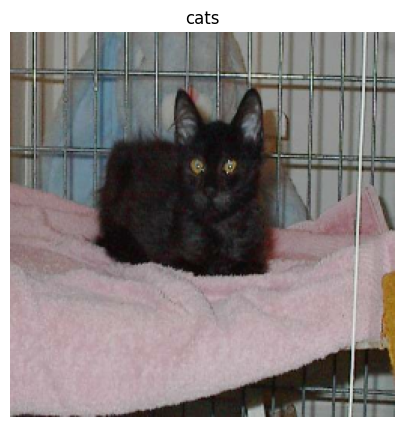

In [6]:
import matplotlib.pyplot as plt

for images_batch, labels_batch in train_ds.take(1):            # taking exactly one batch
    single_image = images_batch[10].numpy().astype('uint8')   
    label_index = labels_batch[10].numpy()
    
    class_names = train_ds.class_names
    image_title = class_names[label_index]
    
    plt.figure(figsize=(5, 5))
    plt.imshow(single_image)
    plt.title(image_title)
    plt.axis("off")
    plt.show()

### Why Resclaing is used in the model below and in what format the image was below ???
When Keras loads the images using the image_dataset_from_directory utility:
* **Single Image Shape**: (255, 255, 3)
  * 255 pixels height
  * 255 pixels width
  * 3 color channels (Red, Green, Blue)
* **Batch Shape**: (32, 255, 255, 3)
  * The dataset feeds the model in groups of 32 images at a time.
* **Original Values**: Raw pixel values are integers ranging from 0 to 255.

### Why Rescaling is Needed
* **Normalizing Range**: Rescaling multiplies all pixel values by 1/255, bringing the range down from [0, 255] to [0.0, 1.0].
* **Training Stability**: Large numbers like 255 can cause numerical instability during backpropagation (exploding gradients), making it difficult for the model to learn.
* **Speed and Performance**: Scaling features to small values (0 to 1) helps the optimizer find the optimal weights much faster and smoother.

In [7]:
model = Sequential([
    # Doing Data Augmentation (Randomly flipping, rotating, and zooming the input images)
    layers.RandomFlip("horizontal", input_shape=(256, 256, 3)),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    
    layers.Rescaling(1./255),                  # resclaing the img btwn 0 to 1 (earlier btwn 0 to 256)

    layers.Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),
    
    layers.Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),
    
    layers.Flatten(),                    # flattening the img matrix
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(64, activation='relu'),
    
    layers.Dense(1, activation='sigmoid')
])

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',      # coz it is a binary classification problem
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs = 10,
    validation_data = val_ds
)

Epoch 1/10


I0000 00:00:1781105966.442613     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 91ms/step - accuracy: 0.5599 - loss: 0.6925 - val_accuracy: 0.6168 - val_loss: 0.6637
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.6392 - loss: 0.6399 - val_accuracy: 0.6967 - val_loss: 0.5859
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.6889 - loss: 0.5872 - val_accuracy: 0.7280 - val_loss: 0.5435
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.7075 - loss: 0.5626 - val_accuracy: 0.7437 - val_loss: 0.5279
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.7274 - loss: 0.5380 - val_accuracy: 0.7567 - val_loss: 0.5039
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.7434 - loss: 0.5170 - val_accuracy: 0.7735 - val_loss: 0.4821
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.7619 - loss: 0.4937 - val_accuracy: 0.7890 - val_loss: 0.4540
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.7631 - loss: 0.4848 - val_accurac

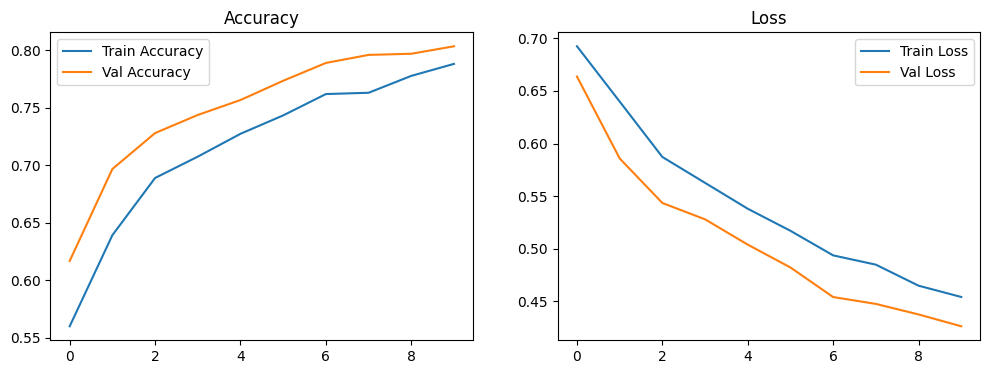

In [9]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

### Making Prediction by putting links of image

112611/112611 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


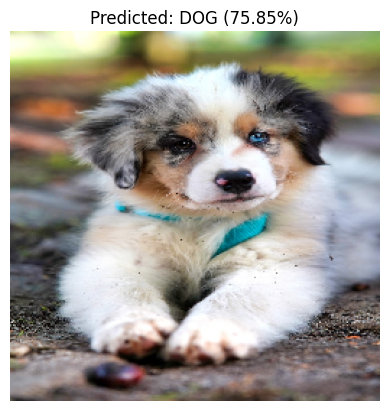

In [21]:
img_url = "https://images.unsplash.com/photo-1601979031925-424e53b6caaa?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

img_path = tf.keras.utils.get_file(origin=img_url)
img = tf.keras.utils.load_img(img_path, target_size=(256,256))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array,0)
prediction = model.predict(img_array)
score = prediction[0][0]
plt.imshow(img)
plt.axis('off')

if score >= 0.5:
        plt.title(f"Predicted: DOG ({score:.2%})")
else:
    plt.title(f"Predicted: CAT ({1 - score:.2%})")
        
plt.show()

44924/44924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


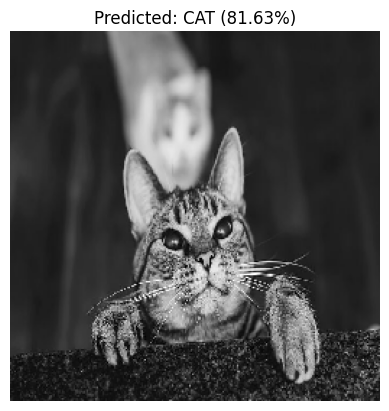

In [24]:
img_url = "https://static.boredpanda.com/blog/wp-content/uploads/2025/05/Cat-Photography-682450da13b37__700.jpg"

img_path = tf.keras.utils.get_file(origin=img_url)
img = tf.keras.utils.load_img(img_path, target_size=(256,256))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array,0)
prediction = model.predict(img_array)
score = prediction[0][0]
plt.imshow(img)
plt.axis('off')

if score >= 0.5:
        plt.title(f"Predicted: DOG ({score:.2%})")
else:
    plt.title(f"Predicted: CAT ({1 - score:.2%})")
        
plt.show()

### Making Prediction

In [25]:
test_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/princelv84/dogsvscats/test",
    image_size=(256,256),
    batch_size=32,
    label_mode="int"
)                            # will automatically find the images in the subfolders

test_loss, test_accuracy = model.evaluate(test_ds)


print(f"\nFinal Test Accuracy: {test_accuracy:.2%}")
print(f"Final Test Loss: {test_loss:.4f}")

Found 5000 files belonging to 2 classes.
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.8020 - loss: 0.4222

Final Test Accuracy: 80.20%
Final Test Loss: 0.4222


In CNNs (and all Keras neural networks), we use three main methods:

1. **model.fit() -> Training**
   * What it does: Trains the model on your training data (updates weights).
   * When to use: At the start of the notebook, to teach the model how to classify.

2. **model.evaluate() -> Scoring**
   * What it does: Computes the overall Accuracy and Loss on a labeled dataset (like the test set).
   * Output: Returns only two numbers (Loss and Accuracy). It does not return individual image guesses.

3. **model.predict() -> Predicting**
   * What it does: Runs the model on new images and returns the actual guess (probability score) for each image.
   * When to use: When you want to find out the model's prediction for specific images.

In [27]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score, f1_score

prediction = model.predict(test_ds)

y_pred = (prediction >= 0.5).astype(int).flatten()

y_true = np.concatenate([y for x, y in test_ds], axis=0)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1 Score:  {f1:.2%}")
print("\nConfusion Matrix:")
print(cm)


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
Accuracy:  50.44%
Precision: 50.41%
Recall:    53.80%
F1 Score:  52.05%

Confusion Matrix:
[[1177 1323]
 [1155 1345]]
